# Projeto 23: Transferência de Aprendizagem


1. Baixando e descompactando as imagens

Link para o dataset: http://web.mit.edu/torralba/www/indoor.html

In [ ]:
# Download do arquivo

In [ ]:
!wget http://groups.csail.mit.edu/vision/LabelMe/NewImages/indoorCVPR_09.tar

--2026-04-21 18:39:09--  http://groups.csail.mit.edu/vision/LabelMe/NewImages/indoorCVPR_09.tar
Resolving groups.csail.mit.edu (groups.csail.mit.edu)... 128.52.131.233
Connecting to groups.csail.mit.edu (groups.csail.mit.edu)|128.52.131.233|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://groups.csail.mit.edu/vision/LabelMe/NewImages/indoorCVPR_09.tar [following]
--2026-04-21 18:39:09--  https://groups.csail.mit.edu/vision/LabelMe/NewImages/indoorCVPR_09.tar
Connecting to groups.csail.mit.edu (groups.csail.mit.edu)|128.52.131.233|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2592010240 (2.4G) [application/x-tar]
Saving to: ‘indoorCVPR_09.tar’

indoorCVPR_09.tar   100%[===================>]   2.41G  10.6MB/s    in 3m 58s  

2026-04-21 18:43:08 (10.4 MB/s) - ‘indoorCVPR_09.tar’ saved [2592010240/2592010240]



In [ ]:
!tar -xvf indoorCVPR_09.tar

A saída de streaming foi truncada nas últimas 5000 linhas.
Images/mall/cover_home3.jpg
Images/mall/CP67791.jpg
Images/mall/crocker_galleria_735089.jpg
Images/mall/mall1.jpg
Images/mall/d8.jpg
Images/mall/deira_city_centre_dubai_08.jpg
Images/mall/dungarv_new_mall.jpg
Images/mall/latham_circle_mall_16.jpg
Images/mall/eastridg1.jpg
Images/mall/IMG_6449.jpg
Images/mall/main_boutique_b.jpg
Images/mall/easyfranchise_centre_commercial_1.jpg
Images/mall/ins42.jpg
Images/mall/mall14.jpg
Images/mall/eaton_centre_2001_03.jpg
Images/mall/ins43.jpg
Images/mall/mall17.jpg
Images/mall/full_shopping_Central_1.jpg
Images/mall/galleria.jpg
Images/mall/galleria1.jpg
Images/mall/galleria2.jpg
Images/mall/Galleria_003.jpg
Images/mall/laurel_mall_06.jpg
Images/mall/Galleria_1.jpg
Images/mall/galleria_san_federico_nr_109_2_n1.jpg
Images/mall/ins23.jpg
Images/mall/ins44.jpg
Images/mall/mall18.jpg
Images/mall/galleria_vittorio_emanuele_ii_milan_mlgalar.jpg
Images/mall/ins45.jpg
Images/mall/mall19.jpg
Images/m

# Nova seção

**Dataset é considerado como indoor scene recognition** , contém imagens internas, pertencentes. Com 77 categorias, locais dos prédios, banheiro, adega de vinhos, 500 mil imagens.

figuras salvas no colab
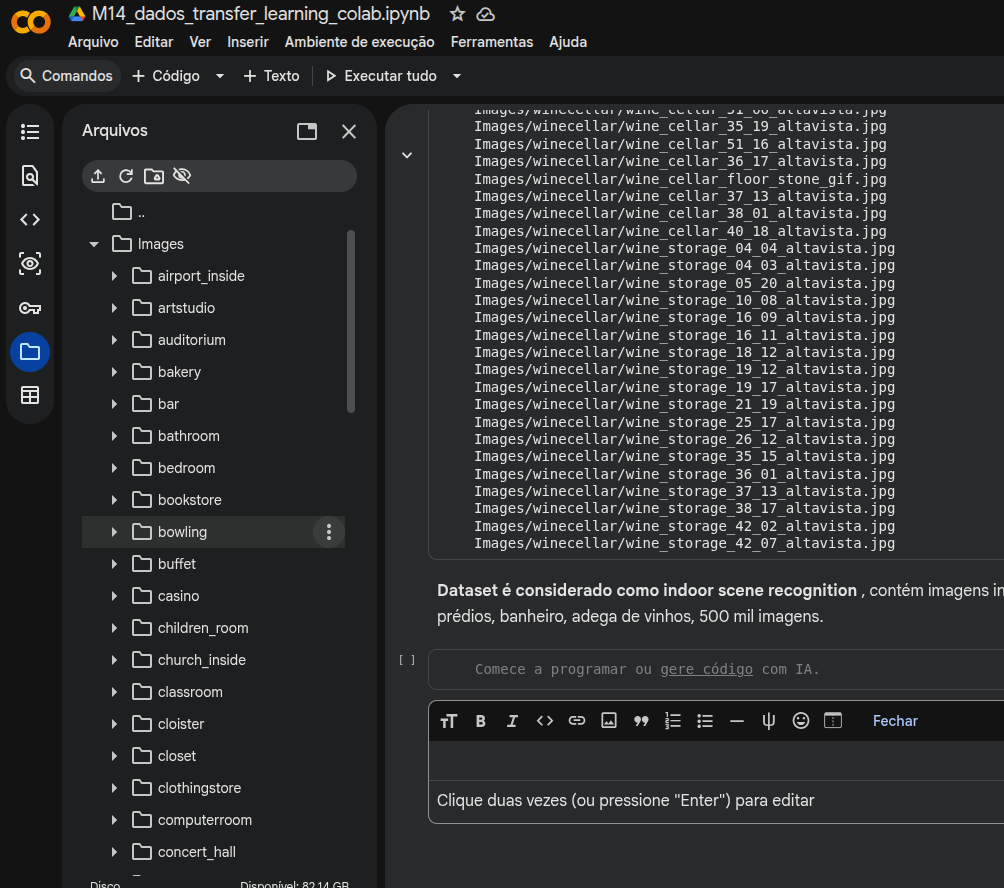

## 2. Preparando as pastas dos datasets

In [ ]:
import os



In [ ]:
# 1. Contagem de arquivos por pasta:
# O os.walk percorre a pasta 'Images' e todas as suas subpastas.
# Para cada pasta encontrada, o len(files) conta quantos arquivos existem dentro dela.
# O 'if len(files) > 0' garante que ele só adicione na lista as pastas que não estão vazias.
num_files_per_folder = [len(files) for root, dirs, files in os.walk('Images') if len(files) > 0]
print(num_files_per_folder) # Ex: [100, 150, 120] (Quantidade de imagens em cada classe)

# 2. Identificação dos nomes das pastas (Categorias):
# Aqui ele busca apenas os nomes dos diretórios dentro de 'Images'.
# O '[0]' no final pega apenas a primeira lista de pastas encontrada (geralmente as pastas das classes).
folders = [dirs for root, dirs, files in os.walk('Images') if len(dirs) > 0][0]  # conter diretório
print('folders')
print(folders) # Ex: [fastfood_restaurant', 'bedroom', 'dining_room']

[116, 662, 274, 101, 269, 197, 127, 101, 233, 107, 107, 103, 513, 108, 135, 135, 175, 380, 157, 706, 539, 144, 515, 120, 101, 125, 114, 101, 127, 176, 276, 131, 103, 151, 213, 249, 608, 405, 110, 457, 140, 168, 153, 166, 180, 258, 506, 103, 213, 176, 106, 347, 384, 346, 155, 174, 239, 734, 103, 112, 113, 111, 116, 102, 604, 109, 231]
folders
['fastfood_restaurant', 'bedroom', 'dining_room', 'lobby', 'winecellar', 'bathroom', 'kindergarden', 'greenhouse', 'meeting_room', 'library', 'restaurant_kitchen', 'prisoncell', 'restaurant', 'studiomusic', 'closet', 'operating_room', 'movietheater', 'bookstore', 'jewelleryshop', 'livingroom', 'subway', 'nursery', 'casino', 'cloister', 'hospitalroom', 'laboratorywet', 'computerroom', 'elevator', 'gameroom', 'auditorium', 'laundromat', 'dentaloffice', 'florist', 'waitingroom', 'grocerystore', 'locker_room', 'airport_inside', 'bakery', 'videostore', 'inside_subway', 'artstudio', 'museum', 'trainstation', 'tv_studio', 'church_inside', 'deli', 'warehou

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
# raiz , diretório e arquivo => root, dirs, files

In [ ]:
num_files_per_folder[:5], folders[:5]

([116, 662, 274, 101, 269],
 ['fastfood_restaurant', 'bedroom', 'dining_room', 'lobby', 'winecellar'])

In [ ]:
num_files_per_folder[:7], folders[:7]

([116, 662, 274, 101, 269, 197, 127],
 ['fastfood_restaurant',
  'bedroom',
  'dining_room',
  'lobby',
  'winecellar',
  'bathroom',
  'kindergarden'])

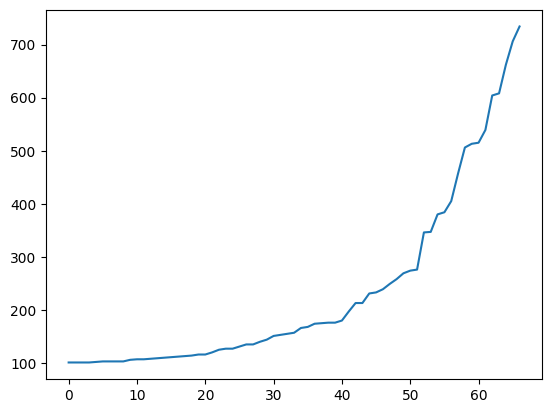

In [ ]:
# visualizar o número dos arquivos por pastas, em ordem crescente

import matplotlib.pyplot as plt
plt.plot(sorted(num_files_per_folder))

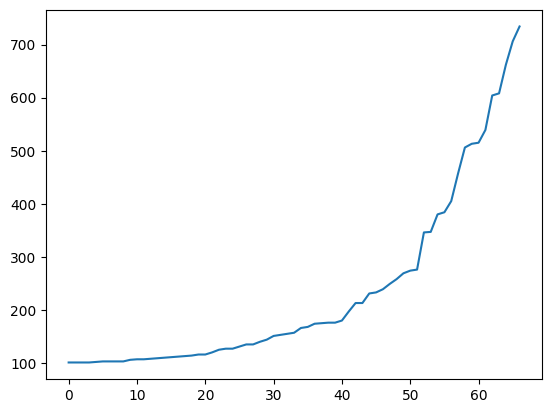

In [ ]:
# 1. Ordenação (sorted):
# O 'sorted()' organiza os números da sua lista (num_files_per_folder) do menor para o maior.
# Isso facilita ver a diferença entre a classe que tem menos imagens e a que tem mais.
dados_ordenados = sorted(num_files_per_folder)

# 2. Plotagem (plt.plot):
# Como você passou apenas uma lista, o Matplotlib usa o índice (0, 1, 2...) no eixo X
# e a quantidade de arquivos no eixo Y.
plt.plot(dados_ordenados)

# Exibe o gráfico na tela
plt.show()

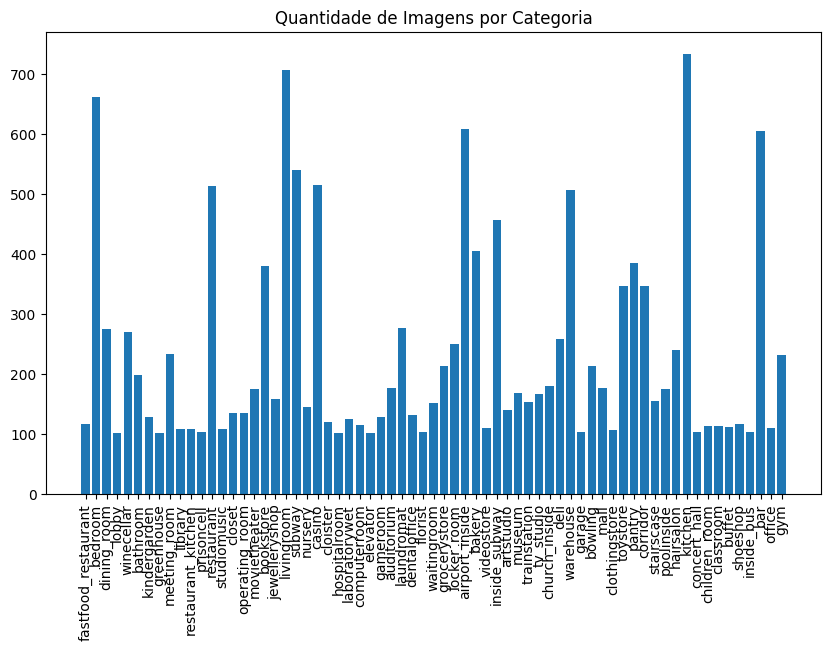

In [ ]:
# Dica: Gráfico de barras com nomes
plt.figure(figsize=(10, 6))
plt.bar(folders, num_files_per_folder)
plt.xticks(rotation=90) # Rotaciona os nomes para não amontoar
plt.title('Quantidade de Imagens por Categoria')
plt.show()

In [ ]:
import numpy as np
# quantas pastas tem mais de 600 imagens
sum(np.array(num_files_per_folder) > 600)

np.int64(5)

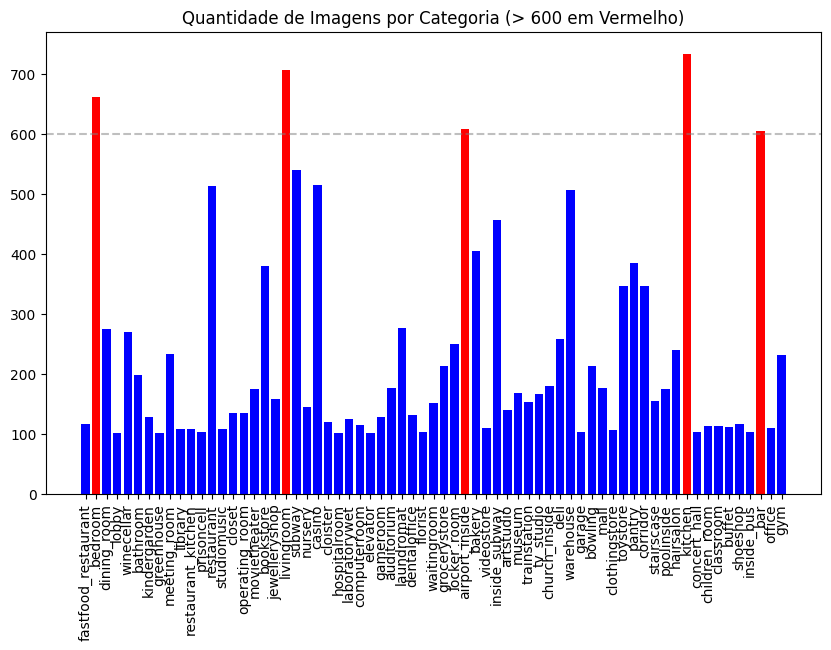

In [ ]:
# 1. Criando a lista de cores condicional:
# Usamos uma "list comprehension": se o valor for > 600, a cor é 'red' (vermelho),
# caso contrário, usamos 'blue' (azul) para as demais.
cores = ['red' if qtd > 600 else 'blue' for qtd in num_files_per_folder]

# 2. Gerando o gráfico com as cores customizadas:
plt.figure(figsize=(10, 6))

# Passamos a lista 'cores' para o parâmetro color
plt.bar(folders, num_files_per_folder, color = cores)

plt.xticks(rotation=90)
plt.title('Quantidade de Imagens por Categoria (> 600 em Vermelho)')

# 3. Opcional: Adicionar uma linha de corte em 600 para facilitar a visualização
plt.axhline(y=600, color='gray', linestyle='--', alpha=0.5)

plt.show()

In [ ]:
# comparar com uma lista para ver valores acima de 600 imagens

In [ ]:
mask = np.array(num_files_per_folder) > 600
folders_to_keep = list(np.array(folders)[mask])
folders_to_keep # pasta que usaremos

[np.str_('bedroom'),
 np.str_('livingroom'),
 np.str_('airport_inside'),
 np.str_('kitchen'),
 np.str_('bar')]

In [ ]:
import shutil
[shutil.rmtree('Images/' + folder) for folder in folders if folder not in folders_to_keep]; # manter as pastas com mais de 600 imagens

agora há apenas as pastas de interesse, com mais de 600 imagens na pasta

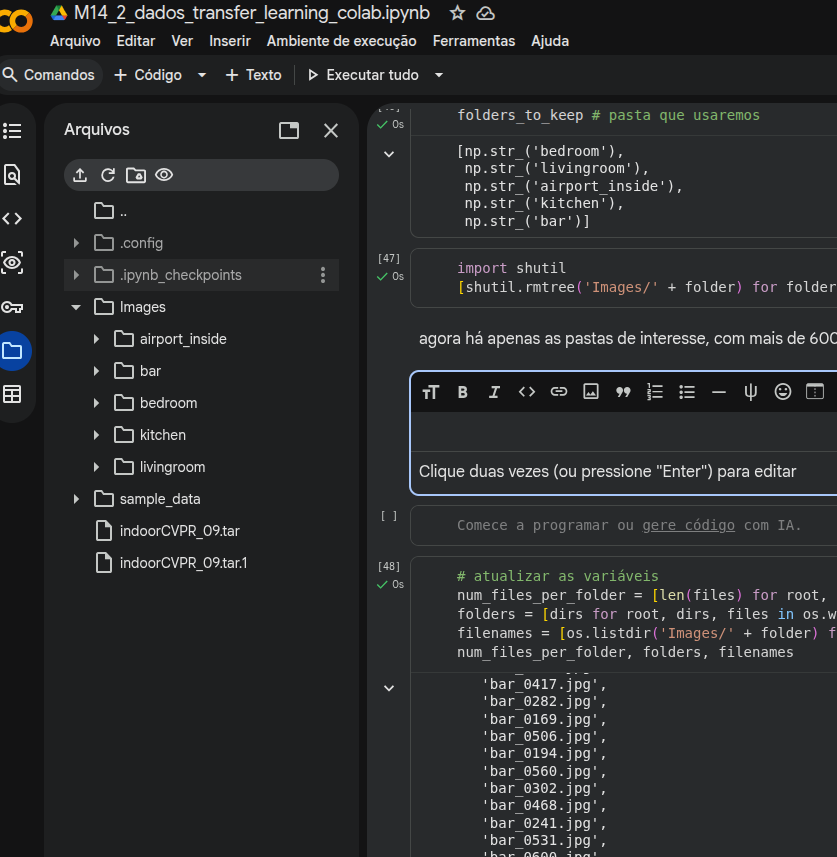

In [ ]:
# atualizar as variáveis
num_files_per_folder = [len(files) for root, dirs, files in os.walk('Images') if len(files) > 0]
folders = [dirs for root, dirs, files in os.walk('Images') if len(dirs) > 0][0]
filenames = [os.listdir('Images/' + folder) for folder in folders]
num_files_per_folder, folders, filenames # nomes dos arquivos

([662, 706, 608, 734, 604],
 ['bedroom', 'livingroom', 'airport_inside', 'kitchen', 'bar'],
 [['IMG_1245.jpg',
   'img_0076.jpg',
   'pasadena_IMG_0150.jpg',
   'indoor_0418.jpg',
   'int486.jpg',
   'indoor_0332.jpg',
   'indoor_0289.jpg',
   'int186.jpg',
   'D02.jpg',
   'int208.jpg',
   'IMG_0994.jpg',
   'indoor_0190.jpg',
   'room301.jpg',
   'room409.jpg',
   'int262.jpg',
   'int184.jpg',
   'indoor_0056.jpg',
   'int231.jpg',
   'int701.jpg',
   'int819.jpg',
   'b23.jpg',
   'int534.jpg',
   'int271.jpg',
   'int152.jpg',
   'indoor_0323.jpg',
   'indoor_0428.jpg',
   'IMG_3264.jpg',
   'room358.jpg',
   'IMG_5744.jpg',
   'int215.jpg',
   'b13.jpg',
   'kamer1g.jpg',
   'chambre1.jpg',
   'int199.jpg',
   'indoor_0305.jpg',
   'int496.jpg',
   'int273.jpg',
   'room158.jpg',
   'indoor_0192.jpg',
   'IMG_0026.jpg',
   'indoor_0503.jpg',
   'OriginalWingRoom15_large.jpg',
   'indoor_0145.jpg',
   'int100.jpg',
   'indoor_0515.jpg',
   'room237.jpg',
   'S03.jpg',
   'int616.j

In [ ]:
# seleção das categorias mais numerosas para a análise

## 2.2 Separação das imagens treino e teste

In [ ]:
np.random.seed(23)
# separar 20% para teste, não ter amostra repetida replace = False
files_to_test = [sorted(np.random.choice(files, round(num_files * 0.2), replace = False)) for files, num_files in zip(filenames, num_files_per_folder)]
files_to_test # lista quais foram selecionados



[[np.str_('2333_2.jpg'),
  np.str_('28042007_001.jpg'),
  np.str_('Gold_Class_600SS_Room_King.jpg'),
  np.str_('IMG_0025.jpg'),
  np.str_('IMG_1246.jpg'),
  np.str_('IMG_1566.jpg'),
  np.str_('IMG_1682.jpg'),
  np.str_('IMG_1683.jpg'),
  np.str_('IMG_2338.jpg'),
  np.str_('IMG_2434.jpg'),
  np.str_('IMG_2830.jpg'),
  np.str_('IMG_3206.jpg'),
  np.str_('IMG_3264.jpg'),
  np.str_('IMG_3265.jpg'),
  np.str_('IMG_4830.jpg'),
  np.str_('IMG_9641.jpg'),
  np.str_('IMG_9642.jpg'),
  np.str_('IMG_9643.jpg'),
  np.str_('IMG_9644.jpg'),
  np.str_('Madison-room.jpg'),
  np.str_('N190002.jpg'),
  np.str_('S02.jpg'),
  np.str_('S03.jpg'),
  np.str_('VA_02_03_9773_33_l.jpg'),
  np.str_('at_00_05_8293_15_l.jpg'),
  np.str_('b15.jpg'),
  np.str_('b18.jpg'),
  np.str_('b19.jpg'),
  np.str_('b29.jpg'),
  np.str_('b30.jpg'),
  np.str_('b7.jpg'),
  np.str_('bed172.jpg'),
  np.str_('bed2.jpg'),
  np.str_('bed8.jpg'),
  np.str_('cdMC1107.jpg'),
  np.str_('chambre22.jpg'),
  np.str_('child4.jpg'),
  np.str_(

In [ ]:
os.mkdir('Images/test/') # criando a pasta que será salva
[os.mkdir('Images/test/' + folder) for folder in folders];
[shutil.move('Images/' + folder + '/' + file, 'Images/test/' + folder + '/' + file) for files, folder in zip(files_to_test, folders) for file in files];

In [ ]:
# os arquivos que sobraram serão treinamentos
os.mkdir('Images/train/')
[shutil.move('Images/' + folder, 'Images/train/' + folder) for folder in folders];

as pastas criadas 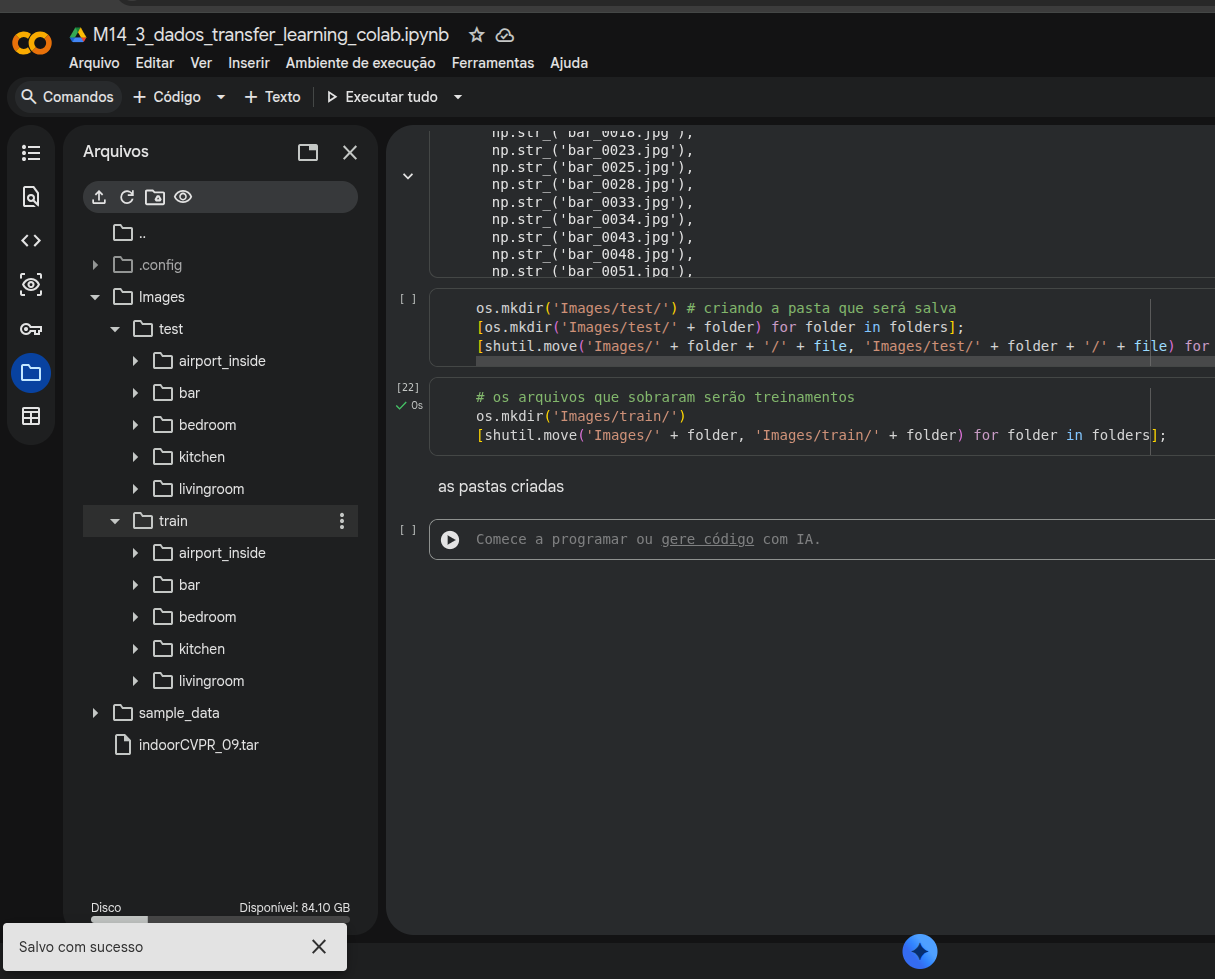

In [ ]:
os.rename('Images', 'dataset')

## 3. Inspeção das imagens

In [ ]:
## 3. Inspeção das imagens
# escolher 4 imagens por categoria

# 1. Mapeamento de todos os arquivos:
# Para cada nome de pasta em 'folders', o listdir entra em 'dataset/train/nome_da_pasta'
# e cria uma sublista com os nomes de todas as imagens que existem lá dentro.
# 'filenames' vira uma lista de listas (uma para cada categoria).
filenames = [os.listdir('dataset/train/' + folder) for folder in folders]

# 2. Seleção Aleatória de Amostras:
# Para cada sublista de arquivos (cada categoria):
# - np.random.choice(files, 4, replace=False): Escolhe 4 imagens aleatoriamente.
# - replace=False: Garante que ele não escolha a mesma imagem duas vezes.
# - sorted(...): Organiza os nomes dos 4 arquivos escolhidos em ordem alfabética.
# 'files_to_visualize' conterá apenas os nomes dos 4 "representantes" de cada pasta.
files_to_visualize = [sorted(np.random.choice(files, 4, replace = False)) for files in filenames]

# Exibe a lista final de nomes de arquivos selecionados
files_to_visualize




[[np.str_('indoor_0221.jpg'),
  np.str_('int213.jpg'),
  np.str_('ph_02_04_4682_01_l.jpg'),
  np.str_('varios_june07_118.jpg')],
 [np.str_('WilsonRoom.jpg'),
  np.str_('at_00_01_8142_31a_l.jpg'),
  np.str_('roomscan19.jpg'),
  np.str_('t_living_room.jpg')],
 [np.str_('airport_inside_0103.jpg'),
  np.str_('airport_inside_0191.jpg'),
  np.str_('airport_inside_0250.jpg'),
  np.str_('airport_inside_0404.jpg')],
 [np.str_('N364077.jpg'),
  np.str_('img_0014.jpg'),
  np.str_('k8.jpg'),
  np.str_('kitchen21.jpg')],
 [np.str_('bar_0042.jpg'),
  np.str_('bar_0115.jpg'),
  np.str_('bar_0465.jpg'),
  np.str_('bar_0537.jpg')]]

In [ ]:
print(files_to_visualize)

[[np.str_('indoor_0221.jpg'), np.str_('int213.jpg'), np.str_('ph_02_04_4682_01_l.jpg'), np.str_('varios_june07_118.jpg')], [np.str_('WilsonRoom.jpg'), np.str_('at_00_01_8142_31a_l.jpg'), np.str_('roomscan19.jpg'), np.str_('t_living_room.jpg')], [np.str_('airport_inside_0103.jpg'), np.str_('airport_inside_0191.jpg'), np.str_('airport_inside_0250.jpg'), np.str_('airport_inside_0404.jpg')], [np.str_('N364077.jpg'), np.str_('img_0014.jpg'), np.str_('k8.jpg'), np.str_('kitchen21.jpg')], [np.str_('bar_0042.jpg'), np.str_('bar_0115.jpg'), np.str_('bar_0465.jpg'), np.str_('bar_0537.jpg')]]


In [ ]:
import pprint

pprint.pprint(files_to_visualize)

[[np.str_('indoor_0221.jpg'),
  np.str_('int213.jpg'),
  np.str_('ph_02_04_4682_01_l.jpg'),
  np.str_('varios_june07_118.jpg')],
 [np.str_('WilsonRoom.jpg'),
  np.str_('at_00_01_8142_31a_l.jpg'),
  np.str_('roomscan19.jpg'),
  np.str_('t_living_room.jpg')],
 [np.str_('airport_inside_0103.jpg'),
  np.str_('airport_inside_0191.jpg'),
  np.str_('airport_inside_0250.jpg'),
  np.str_('airport_inside_0404.jpg')],
 [np.str_('N364077.jpg'),
  np.str_('img_0014.jpg'),
  np.str_('k8.jpg'),
  np.str_('kitchen21.jpg')],
 [np.str_('bar_0042.jpg'),
  np.str_('bar_0115.jpg'),
  np.str_('bar_0465.jpg'),
  np.str_('bar_0537.jpg')]]


In [ ]:
# exemplo do algoritmo vai usar no modelo

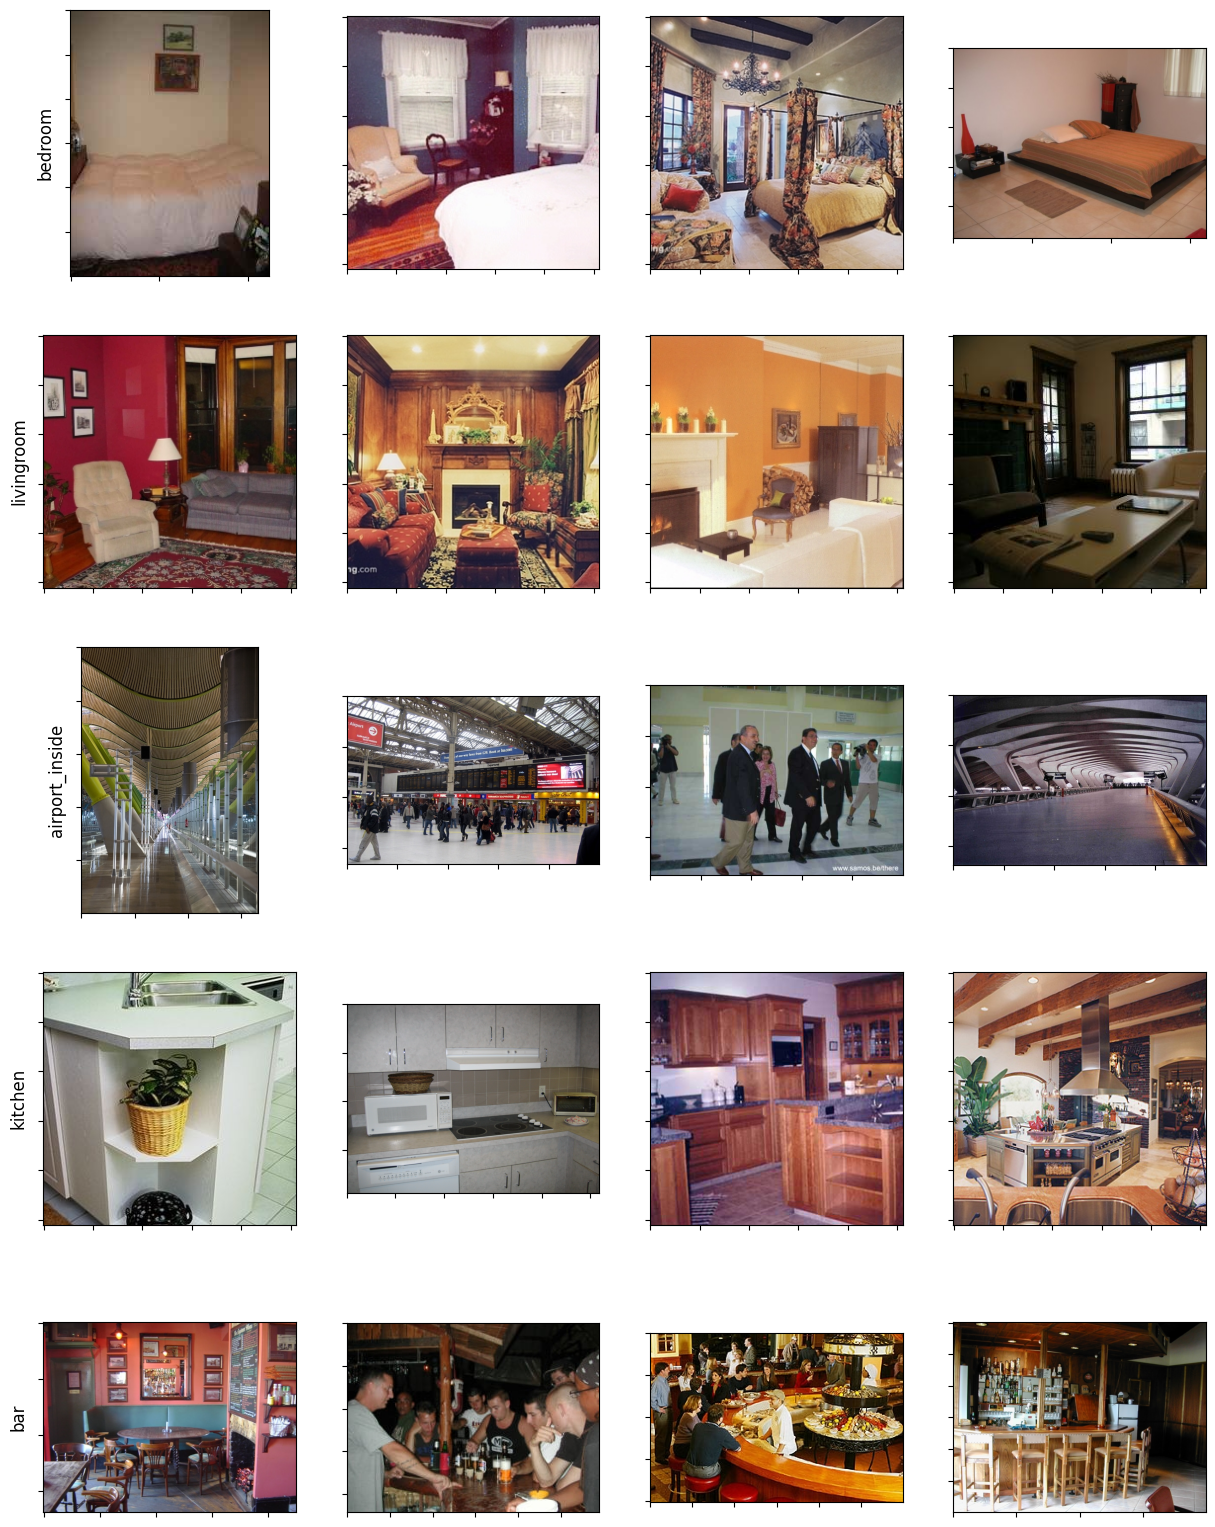

In [ ]:
# 1. Cria o "Grid" de Imagens:
# Cria uma figura com 5 linhas (categorias) e 4 colunas (amostras por categoria).
# O figsize=(15, 20) garante que as imagens fiquem grandes o suficiente para serem vistas.
fig, ax = plt.subplots(5, 4, figsize = (15, 20))

# 2. Loop pelas Linhas (Categorias):
for row in range(5):
    category = folders[row]  # Pega o nome da pasta (ex: 'bedroom')
    ax_row = ax[row]         # Seleciona a linha atual do grid

    # 3. Loop pelas Colunas (Amostras):
    for column in range(4):
        # Carrega a imagem do disco usando o caminho completo
        img = plt.imread('dataset/train/' + category + '/' + files_to_visualize[row][column])

        ax_column = ax_row[column] # Seleciona o "quadradinho" específico (eixo)
        ax_column.imshow(img)      # Desenha a imagem no quadradinho

        # 4. Organização e Estética:
        # Se for a primeira imagem da linha, coloca o nome da categoria na lateral (Y)
        if column == 0:
            ax_column.set_ylabel(category, size = 'large')

        # Remove as coordenadas (números dos eixos X e Y) para o gráfico ficar limpo
        ax_column.set_xticklabels([])
        ax_column.set_yticklabels([])

## 4. Preparando os datasets para uso no Pytorch

colocar os datasets no formato pytorch

In [ ]:

# 1. Ferramentas Principais do PyTorch:
import torch           # A biblioteca base (como o NumPy, mas com suporte a GPU e Gradientes).
import torch.nn as nn  # Contém as peças para montar a rede (camadas lineares, convoluções, etc).
import torch.nn.functional as F # Funções que não guardam estado (como ativações ReLU ou Softmax).
from torch import optim # Algoritmos de otimização (Adam, SGD) para treinar o modelo.

# 2. Ferramentas de Visão Computacional (Torchvision):
from torchvision import datasets, models # Permite baixar datasets famosos e modelos prontos (ResNet, VGG).
import torchvision.transforms as transforms # Essencial para redimensionar e normalizar suas imagens.

# 3. Utilidades:
from datetime import datetime # Útil para marcar quanto tempo o treinamento levou ou salvar modelos com data.

# Reprodutibilidade
# 4. Reprodutibilidade:
# Define uma 'semente' (seed) para os geradores de números aleatórios.
# Isso garante que, se você rodar o código hoje e amanhã, os pesos iniciais
# e o embaralhamento dos dados sejam IGUAIS, facilitando a comparação de resultados.
torch.manual_seed(124);



In [ ]:
# redimensionar as imagens

data_dir_train = 'dataset/train'
data_dir_test = 'dataset/test'

# Exemplo do que costuma vir agora:
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Deixa todas as fotos do mesmo tamanho
    transforms.ToTensor(),          # Transforma a imagem em números (0 a 1)
  #  transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Padroniza as cores
])

#Carregamento do Dataset (datasets.ImageFolder)
#O PyTorch olha para as pastas com o os.walk e cria um objeto que sabe qual imagem pertence a qual categoria.
train_dataset = datasets.ImageFolder(data_dir_train, transform = transform)
#3. Criação do DataLoader
#cria o "motor" que vai entregar as imagens em pacotes (batches) para a GPU.
#shuffle = True no seu DataLoader faz o embaralhamento dos dados antes de cada época de treinamento.
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = 32, shuffle = True)

test_dataset = datasets.ImageFolder(data_dir_test, transform = transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size = 32, shuffle = True)

## 5. Definindo o modelo e parâmetros de treinamento

In [ ]:
#baixando a arquitetura da VGG16 com todos os pesos (filtros) já treinados no banco de dados ImageNet.
#já sabe identificar bordas, texturas, olhos, rodas e cores.

In [ ]:
# baixar a estrutura de rede, importando os parâmetros internos, os pesos
# hoje a rede foi treinada
model = models.vgg16(pretrained = True)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:04<00:00, 136MB/s]


In [ ]:
# features e classificação
print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

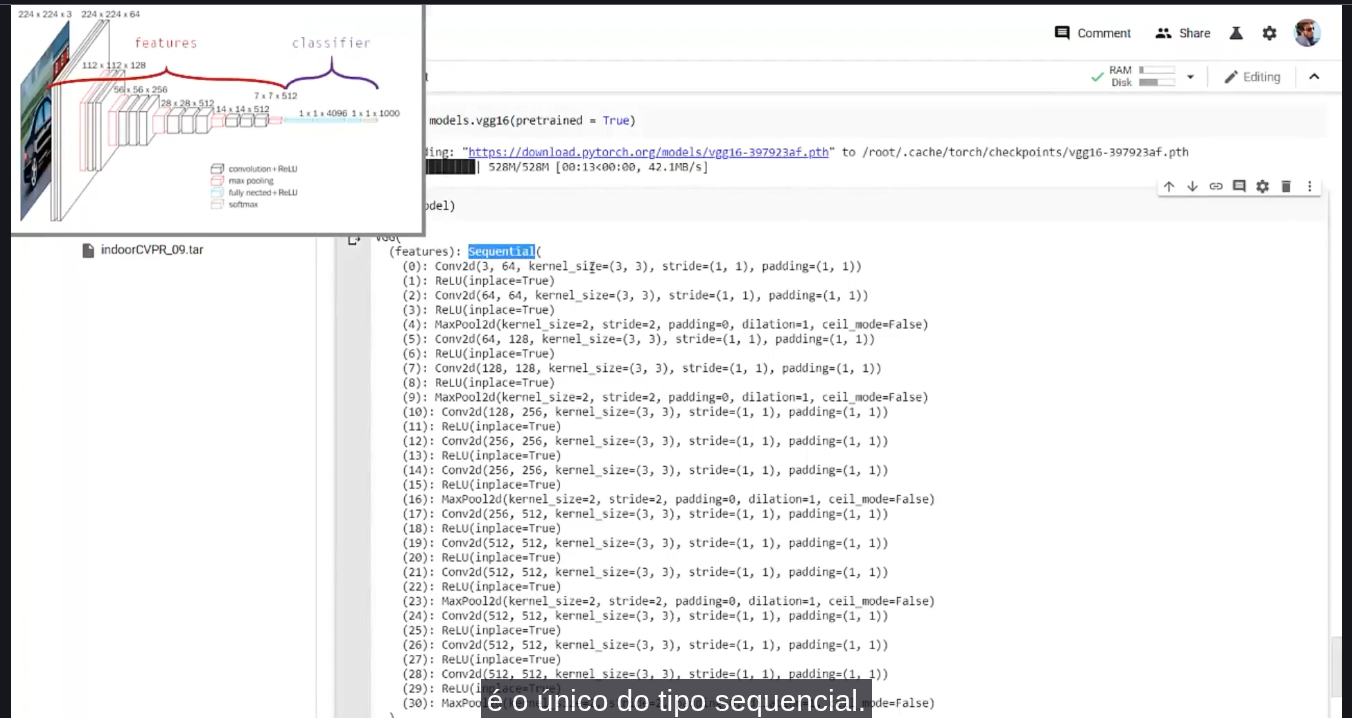

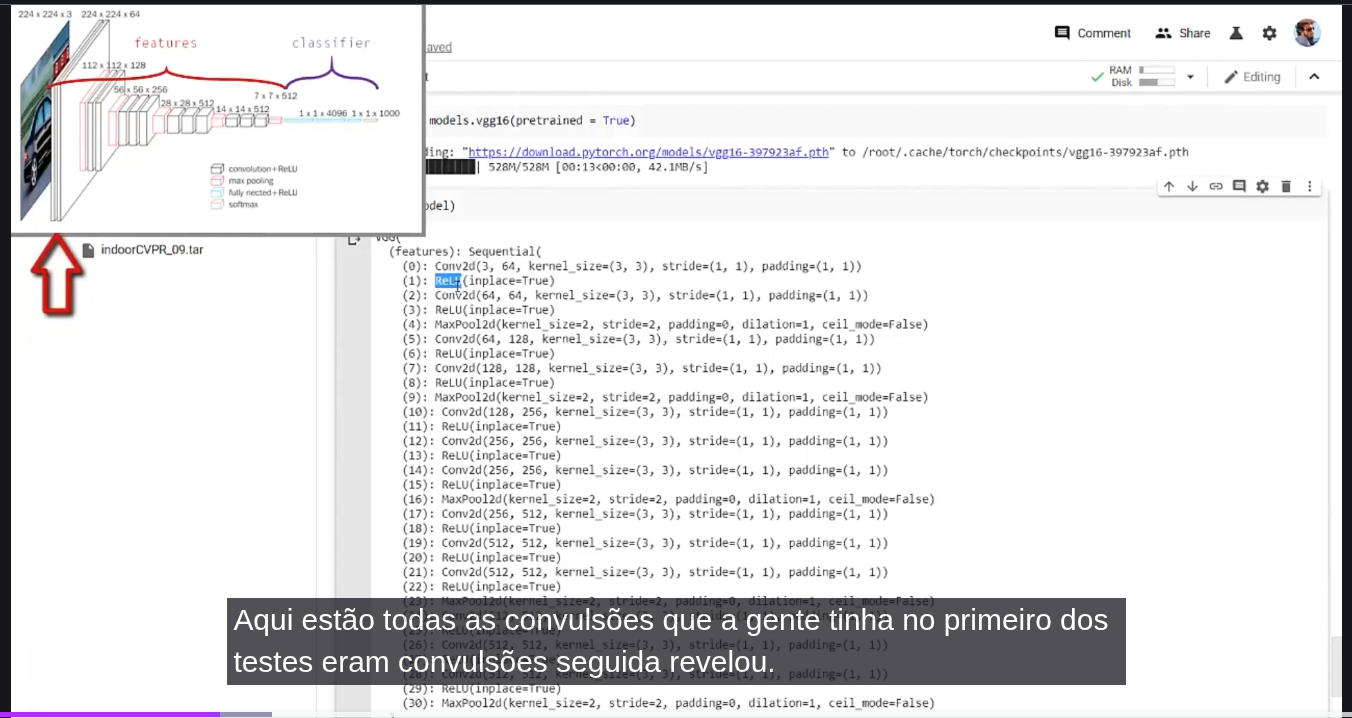

adaptiveAvgPoll2d somarizar os dados features, passar o modulo de classificação, 3 modulos lineares

# vtor com 1000 categorias, mas estamos apenas usando 5 categorias

In [ ]:
# recuperar o número de inputs
#A VGG16 termina com uma camada que classifica 1.000 coisas.
#Perguntando ao PyTorch: "Quantas conexões entram na última camada da VGG?".
#No caso da VGG16, a resposta é 4096. Esse número é guardado em n_inputs.
n_inputs = model.classifier[6].in_features

#cria uma nova camada linear personalizada.
#recebe as 4.096 características e as transforma no número exato de classes que tem no seu projeto
# (por exemplo, se você tem 5 pastas de imagens, a saída será 5).
classification_layer = nn.Linear(n_inputs, len(train_dataset.classes)) # camada densa agora, entrada dos dados, e len comprimento e número de classes

#"arranca" a última camada original (que servia para 1.000 classes) e coloca a sua camada nova no lugar.
# Agora, a rede vai usar todo o "cérebro" da VGG, mas a resposta final será focada apenas nas suas imagens.
model.classifier[6] = classification_layer

#Se o resultado for, por exemplo, (4096, 5), isso confirma que:
#a rede recebe 4.096 informações complexas da imagem.
#Ela agora está configurada para decidir entre 5 categorias possíveis.

n_inputs, len(train_dataset.classes)

(4096, 5)

In [ ]:
# perde os pesos da última vez


In [ ]:
print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
#Linear (in_features=4096, outfeares=1000, bias= Trues
#problema irrelavante, treinada do zero, perdendo os pesos, mas aproveitando os outros dados
#find tunes
 #congelaremos as camadas de features, processo demoraria mais
 # mas se quiser não precisa congelar

In [ ]:
# 1. 'model.features': Refere-se a toda a parte de visão da rede (as convoluções).
# 2. 'parameters()': Acessa cada filtro e peso que a VGG16 aprendeu no ImageNet.
# 3. 'param.requires_grad = False': Desliga o cálculo do gradiente para esses parâmetros.
for param in model.features.parameters():
    param.requires_grad = False # atributos sem gradiente inspecionado,

In [ ]:
print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
# critério de perda
# --- 1. CONFIGURAÇÃO DA FUNÇÃO DE PERDA (O JUIZ) ---
# O CrossEntropyLoss é ideal para classificação de várias categorias (classes).
# Ele calcula a diferença entre o que a rede "chutou" e a resposta real.
criterion = nn.CrossEntropyLoss()

# --- 2. CONFIGURAÇÃO DO OTIMIZADOR (O TREINADOR) ---
# O Adam é um algoritmo que ajusta os pesos da rede para diminuir o erro.
# Ele recebe 'model.parameters()', mas como congelamos as camadas anteriores,
# o Adam vai focar apenas em treinar a nossa nova camada final.
optimizer = optim.Adam(model.parameters())

## 6. Treinamento e validação

In [ ]:
## 6. Treinamento e validação
# 1. DETECÇÃO DE HARDWARE:
# O 'torch.cuda.is_available()' verifica se o computador tem uma placa de vídeo NVIDIA instalada e configurada.
# Se existir (True), ele define o dispositivo como 'cuda'.
# Se não existir (False), ele define como 'cpu'.
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# 2. TRANSFERÊNCIA DO MODELO:
# Por padrão, o PyTorch cria o modelo na memória RAM do computador (CPU).
# O '.to(device)' move todos os milhares de parâmetros e pesos da rede para a memória da GPU.
model.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
# treinamento
def training_loop(loader, epoch):

    # Variáveis para acumular perda e precisão
    # Inicializa acumuladores para calcular a média no final da época
    running_loss = 0.
    running_accuracy = 0.

    # Itera sobre os pacotes (batches) de imagens do loader
    for i, data in enumerate(loader):
        # Itera sobre os pacotes (batches) de imagens do loader
        inputs, labels = data
        # Envia os dados para a GPU (ou CPU) definida anteriormente
        inputs, labels = inputs.to(device), labels.to(device)

        # Zera os gradientes acumulados para não somar o erro do loop anterior
        optimizer.zero_grad()

        # Forward: A rede tenta adivinhar o que tem na imagem
        # gerar a saída
        outputs = model(inputs)
        # Calcula o erro (perda) comparando o palpite com a realidade
        loss = criterion(outputs, labels)
        # Backward: O PyTorch calcula como ajustar cada peso para diminuir o erro
        loss.backward()

        # O otimizador (Adam) efetivamente altera os pesos da rede
        optimizer.step()
        # Acumula a perda para o relatório final
        running_loss += loss.item()

        # Como `output` não passou por ativação**, vamos fazer isso agora usando a função `F.softmax`**.
        #Em seguida, usamos `torch.argmax` para retornar o índice mais alto, que corresponde à predição.
        # Transforma a saída da rede em probabilidades e pega a maior delas
        predicted = torch.argmax(F.softmax(outputs, dim = 1), dim = 1)

        # Agora podemos ver quantas predições o modelo acertou
        # Compara as predições com os rótulos reais (True se acertou, False se errou)
        equals = predicted == labels

        # A precisão será igual à média da variável anterior (número de `True` dividido pelo total)
        # Calcula a média de acertos neste pacote (batch)
        accuracy = torch.mean(equals.float())
        running_accuracy += accuracy

        # Imprimindo os dados referentes a este loop
        # Print de acompanhamento em tempo real
        print('Época {} | loop {}/{}: perda {:.5f} - precisão {:.5f}'.format(epoch + 1, i + 1, len(loader), loss.item(), accuracy))

    # Calcula e imprime as médias finais da época

    # Imprimindo os dados referentes a esta época
    epoch_loss = running_loss/len(loader)
    epoch_acc = running_accuracy/len(loader)
    print('>>>>> ÉPOCA {} FINALIZADA: perda {:.5f} - precisão {:.5f}'.format(epoch + 1, running_loss/len(loader), running_accuracy/len(loader)))

    return epoch_loss, epoch_acc # Retornamos os valores para poder plotar o gráfico depois

Treinando...
Época 1 | loop 1/83: perda 1.68506 - precisão 0.37500
Época 1 | loop 2/83: perda 3.34871 - precisão 0.09375
Época 1 | loop 3/83: perda 2.43339 - precisão 0.40625
Época 1 | loop 4/83: perda 2.48208 - precisão 0.21875
Época 1 | loop 5/83: perda 1.35375 - precisão 0.40625
Época 1 | loop 6/83: perda 1.45098 - precisão 0.37500
Época 1 | loop 7/83: perda 1.45861 - precisão 0.40625
Época 1 | loop 8/83: perda 1.76349 - precisão 0.21875
Época 1 | loop 9/83: perda 1.71974 - precisão 0.28125
Época 1 | loop 10/83: perda 1.20508 - precisão 0.50000
Época 1 | loop 11/83: perda 1.49641 - precisão 0.43750
Época 1 | loop 12/83: perda 1.65441 - precisão 0.46875
Época 1 | loop 13/83: perda 1.43875 - precisão 0.40625
Época 1 | loop 14/83: perda 1.46170 - precisão 0.56250
Época 1 | loop 15/83: perda 0.78711 - precisão 0.68750
Época 1 | loop 16/83: perda 1.24422 - precisão 0.43750
Época 1 | loop 17/83: perda 0.98424 - precisão 0.56250
Época 1 | loop 18/83: perda 1.00487 - precisão 0.65625
Época 

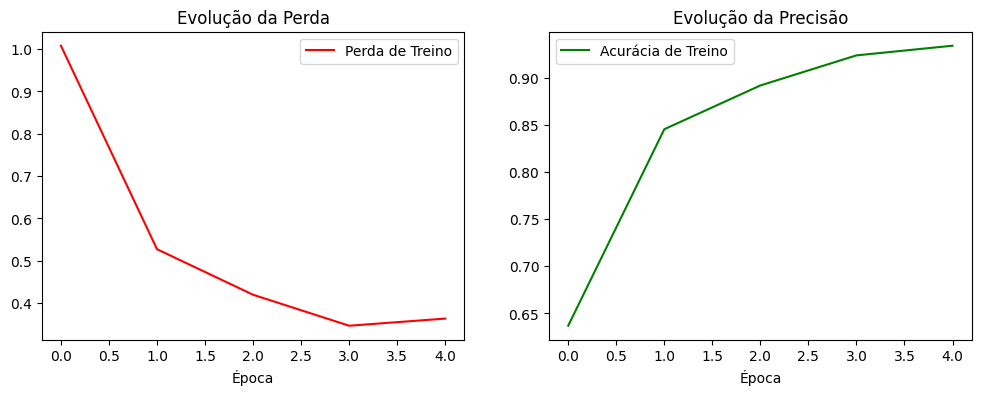

In [ ]:
# 1. Criar listas para armazenar o histórico
historico_perda = []
historico_acuracia = []

start = datetime.now() # horário que inicio o programa treinamento
for epoch in range(5): # pode rodar de 30 e 20, mas o transfer já treinou exaustivamente antes, por isso 5
    print('Treinando...')
    # adaptado
    loss, acc =  training_loop(train_loader, epoch)
    historico_perda.append(loss)
    historico_acuracia.append(acc.cpu().numpy()) # Move para CPU para o gráfico
    # volta, antes era somente o training_loop(train_loader, epoch)
    model.eval()
    print('Validando...')
    training_loop(test_loader, epoch)
    model.train()
end = datetime.now() # horário que terminou o treinamento

print('Treinamento/validação demorou {}'.format(end - start))


# 3. Criar o gráfico
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Gráfico de Perda (Loss) - Deve diminuir
plt.subplot(1, 2, 1)
plt.plot(historico_perda, label='Perda de Treino', color='red')
plt.title('Evolução da Perda')
plt.xlabel('Época')
plt.legend()

# Gráfico de Precisão (Accuracy) - Deve aumentar
plt.subplot(1, 2, 2)
plt.plot(historico_acuracia, label='Acurácia de Treino', color='green')
plt.title('Evolução da Precisão')
plt.xlabel('Época')
plt.legend()

plt.show()

precisão alta de 93%, e 95% no treino

Evolução da Perda (Gráfico Vermelho)
Este gráfico mede o "erro" do modelo.

O que aconteceu: A curva desce drasticamente da época 0 para a 1 e continua caindo até a época 3.

Significado: Isso indica que o otimizador (Adam) está conseguindo ajustar os pesos da camada final com eficiência. A rede está deixando de "chutar" e passando a ter certeza sobre as classes.

Ponto de atenção: Note que entre a época 3 e 4, a linha parou de cair e deu uma leve subidinha. Isso sugere que 5 épocas foram o número ideal. Se continuassemos treinando por 20 ou 30 épocas, a perda poderia começar a subir, gerando o overfitting (quando a rede decora o treino mas falha na vida real).

2. Evolução da Precisão (Gráfico Verde)
Este gráfico mostra a porcentagem de acertos (Acurácia).

O que aconteceu: Você começou com pouco mais de 60% (o que já é bom para um começo aleatório) e terminou em quase 95%.

Significado: Um resultado de ~94% de acurácia com apenas 5 épocas é excelente! Isso é o poder do Transfer Learning: como a VGG16 já "sabe ver", ela só precisou de um pequeno ajuste para entender o seu dataset específico.

In [ ]:
# gpu é para deixar o processo mais rápido também


gráfico

Perda (Loss): A curva vermelha deve descer. Se ela estiver subindo ou oscilando muito, a "Taxa de Aprendizado" (Learning Rate) pode estar alta demais.

Precisão (Accuracy): A curva verde deve subir. Como está sendo usado a VGG16 (uma rede potente), é comum ela subir rápido logo nas primeiras épocas.

In [44]:
#a validação poderia ser feito assim, no teste
# Crie uma função separada para validar, ou adicione um 'if' na original
# para teste, caso necessário
def validation_loop_para_teste(loader, epoch):
    model.eval() # Garante que está em modo de avaliação
    running_loss = 0.
    running_accuracy = 0.

    # O 'torch.no_grad()' desativa o cálculo de gradientes,
    # economizando memória e impedindo o modelo de "aprender" com o teste
    with torch.no_grad():
        for i, data in enumerate(loader):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            predicted = torch.argmax(F.softmax(outputs, dim=1), dim=1)
            accuracy = torch.mean((predicted == labels).float())
            running_accuracy += accuracy

    print('>>>>> VALIDAÇÃO FINALIZADA: perda {:.5f} - precisão {:.5f}'.format(
        running_loss/len(loader), running_accuracy/len(loader)))

    return running_loss/len(loader), running_accuracy/len(loader)

## 7. Verificação

In [46]:
## 7. Verificação

# predição da categoria


In [58]:
# 1. PEGA UMA AMOSTRA DE TESTE:
# O iter() cria um iterador sobre o test_loader e o next() extrai o primeiro grupo (batch).
# 'images' contém os tensores das fotos e 'labels' contém as categorias corretas (gabarito).
images, labels = next(iter(test_loader))

# 2. MODO DE AVALIAÇÃO:
# Avisa ao PyTorch que não estamos mais treinando. Isso é vital para que o modelo
# use os pesos fixos e desative camadas como o Dropout, dando um resultado estável.
model.eval()

# 3. REALIZA A PREDIÇÃO:
# Envia as imagens para a GPU (device), passa pela rede (model) e traz o
# resultado de volta para a memória comum (cpu) para que possamos ler.
predicted = model(images.to(device)).cpu()

# 4. TRANSFORMA EM CLASSE:
# O modelo retorna 'logits' (valores brutos). O Softmax transforma em probabilidades
# e o argmax pega o índice da maior probabilidade (a classe que a rede "acha" que é a certa).
predicted = torch.argmax(F.softmax(predicted, dim = 1), dim = 1)

# 5. MOSTRA O RESULTADO:
# Exibe um tensor com os números das classes que o modelo previu para as imagens do batch.
predicted

tensor([4, 2, 3, 1, 1, 3, 2, 3, 0, 3, 2, 3, 4, 4, 4, 2, 1, 1, 1, 4, 0, 0, 2, 3,
        2, 1, 0, 1, 0, 4, 4, 2])

In [59]:
# a gente quer a resposta em nomes, e não em números. Ajustando:

# Exibe o mapeamento entre o nome textual da categoria e o número inteiro correspondente.
# O PyTorch faz isso em ordem alfabética por padrão.
# Exemplo de saída: {'airport_inside': 0, 'bar': 1, 'bedroom': 2, 'kitchen': 3, 'livingroom': 4}
test_dataset.class_to_idx

{'airport_inside': 0, 'bar': 1, 'bedroom': 2, 'kitchen': 3, 'livingroom': 4}

In [60]:
#list comprehension
idx_to_class = {k: v for v, k in test_dataset.class_to_idx.items()}
idx_to_class # dicionário invertido

{0: 'airport_inside', 1: 'bar', 2: 'bedroom', 3: 'kitchen', 4: 'livingroom'}

In [61]:
# rótulo das categorias reais e previsão
# transforma o tensor em numpy

labels, predicted = labels.detach().numpy(), predicted.detach().numpy()


In [62]:
# 1. TRADUÇÃO DOS RÓTULOS REAIS (GABARITO):
# Para cada número na lista 'labels', ele busca o nome correspondente no dicionário 'idx_to_class'.
# Se labels era [0, 1], agora será [airport_inside', 'bar] (exemplo).
labels = [idx_to_class[label] for label in labels]

# 2. TRADUÇÃO DAS PREVISÕES DO MODELO:
# Faz o mesmo processo para a lista 'predicted'.
# Transforma os palpites numéricos da rede neural em nomes legíveis.
predicted = [idx_to_class[label] for label in predicted]

# 3. EXIBIÇÃO:
# Mostra as duas listas lado a lado para você comparar visualmente se o modelo acertou.
labels, predicted

(['livingroom',
  'bedroom',
  'kitchen',
  'bar',
  'bar',
  'kitchen',
  'bedroom',
  'kitchen',
  'airport_inside',
  'kitchen',
  'bedroom',
  'kitchen',
  'livingroom',
  'livingroom',
  'livingroom',
  'bedroom',
  'bar',
  'bar',
  'bar',
  'livingroom',
  'airport_inside',
  'airport_inside',
  'bedroom',
  'kitchen',
  'bedroom',
  'bar',
  'airport_inside',
  'bar',
  'airport_inside',
  'livingroom',
  'livingroom',
  'bedroom'],
 ['livingroom',
  'bedroom',
  'kitchen',
  'bar',
  'bar',
  'kitchen',
  'bedroom',
  'kitchen',
  'airport_inside',
  'kitchen',
  'bedroom',
  'kitchen',
  'livingroom',
  'livingroom',
  'livingroom',
  'bedroom',
  'bar',
  'bar',
  'bar',
  'livingroom',
  'airport_inside',
  'airport_inside',
  'bedroom',
  'kitchen',
  'bedroom',
  'bar',
  'airport_inside',
  'bar',
  'airport_inside',
  'livingroom',
  'livingroom',
  'bedroom'])

In [63]:
images.shape

torch.Size([32, 3, 224, 224])

In [64]:
# Mostra o formato (shape) do tensor de imagens.
# O resultado será algo como: torch.Size([32, 3, 224, 224])
images.shape
#32 (Batch Size): É a quantidade de imagens que pegamos de uma vez só (o seu "pacote").

#3 (Canais): Representa as cores RGB (Red, Green, Blue). Se fosse 1, a imagem seria em tons de cinza.

#224 (Altura): A quantidade de pixels na vertical.

#224 (Largura): A quantidade de pixels na horizontal.

torch.Size([32, 3, 224, 224])

In [65]:
# permuta as imagens

# 1. PERMUTE(0, 2, 3, 1):
# O PyTorch usa o padrão (Canais, Altura, Largura).
# O Matplotlib/Numpy usa o padrão (Altura, Largura, Canais).
# Este comando troca a ordem: o canal (índice 1) vai para o final da fila (índice 3).
#torch.Size([32, 3, 224, 224])# 0,1,2,3

# 2. NUMPY():
# Converte o tensor do PyTorch em uma matriz do Numpy.
# Isso é necessário porque bibliotecas de visualização não entendem tensores do PyTorch diretamente.

images = images.permute(0, 2, 3, 1).numpy()

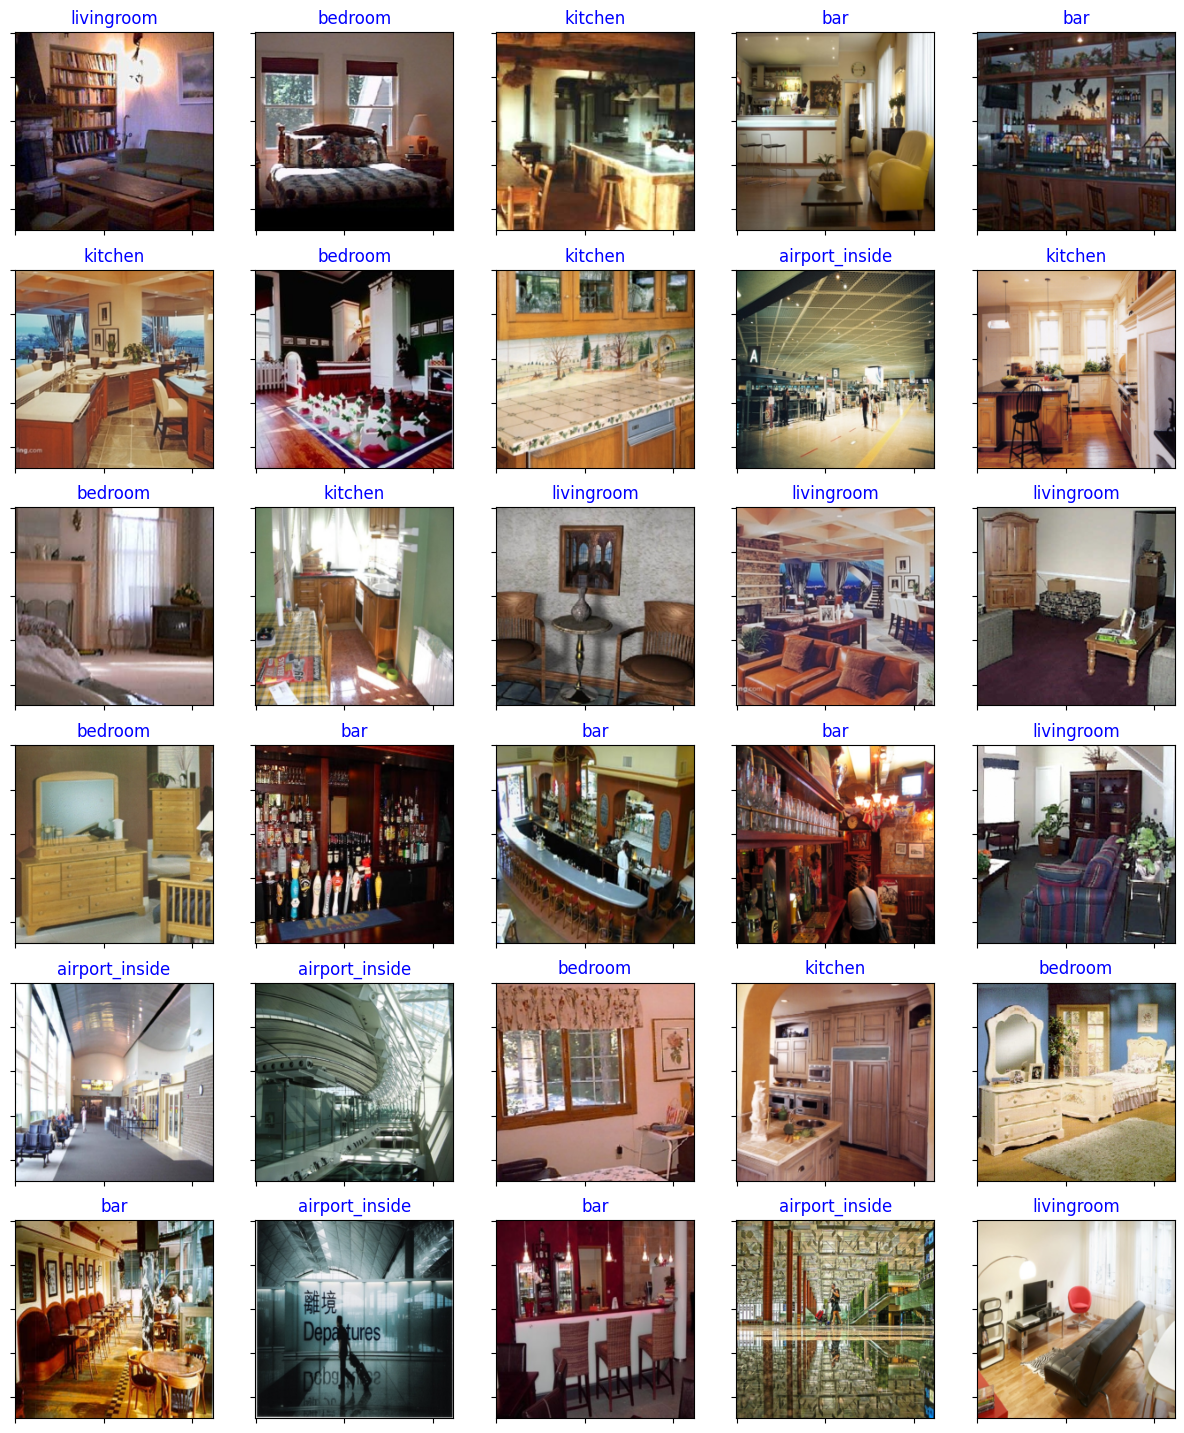

In [66]:
# 1. CRIAÇÃO DA GRADE (CANVAS):
# Cria uma figura com 30 subgráficos organizados em 6 linhas e 5 colunas.
# 'figsize' define o tamanho da imagem final para que não fique tudo apertado.
fig, ax = plt.subplots(6, 5, figsize = (15, 18))

i = 0
# 2. LOOP PELAS LINHAS E COLUNAS:
for row in range(6):
    ax_row = ax[row] # Seleciona a linha atual
    for column in range(5):
        ax_column = ax_row[column] # Seleciona o "quadradinho" (eixo) atual

        # 3. MOSTRAR A IMAGEM:
        # Coloca a imagem 'i' no quadradinho correspondente.
        ax_column.imshow(images[i])

        # 4. LIMPEZA VISUAL:
        # Remove os números dos eixos X e Y (coordenadas de pixels) para o gráfico ficar limpo.
        ax_column.set_xticklabels([])
        ax_column.set_yticklabels([])

        # 5. LÓGICA DE COR (O PULO DO GATO):
        # Se o modelo acertou (label == predicted), a cor será azul.
        # Se o modelo errou, a cor será vermelha.
        col = 'blue' if labels[i] == predicted[i] else 'red'

        # 6. TÍTULO:
        # Escreve o nome da classe que o modelo previu no topo da imagem com a cor definida.
        ax_column.set_title(predicted[i], color = col)

        i += 1 # Passa para a próxima imagem